# 04 - Results and Error Analysis

This notebook presents the final score, repository and class results, confusion matrix, and most frequent errors from the saved predictions.


## Step 1 - Locate the project and load final outputs


In [1]:
# Step 1: Locate the project root and import our package from src/.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src" / "issue_classifier").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not find AI4SE_FINAL_PROJECT/src/issue_classifier")
    PROJECT_ROOT = PROJECT_ROOT.parent

source_dir = str(PROJECT_ROOT / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\AI4SE_FINAL_PROJECT


In [2]:
# Step 1: Load the saved metrics and predictions used by the report.
import json
import pandas as pd
from IPython.display import Image, display

result_dir = PROJECT_ROOT / "results" / "chosen-model-seed42"
metrics = json.loads((result_dir / "metrics.json").read_text(encoding="utf-8"))
predictions = pd.read_csv(result_dir / "predictions.csv")
primary = metrics["policies"]["primary"]


## Step 2 - Present the headline comparison


In [3]:
# Step 2: Compare our chosen-model score with the published NLBSE'24 results.
comparison = pd.DataFrame(
    [
        ["Our chosen model", primary["global"]["macro_f1"]],
        ["NLBSE'24 detailed SetFit", 0.823973],
        ["NLBSE'24 headline SetFit", 0.827000],
        ["NLBSE'24 RoBERTa", 0.792000],
        ["NLBSE'24 fastText", 0.718000],
    ],
    columns=["system", "cross_repository_macro_f1"],
)
comparison.style.format({"cross_repository_macro_f1": "{:.6f}"})


,system,cross_repository_macro_f1
0,Our chosen model,0.754385
1,NLBSE'24 detailed SetFit,0.823973
2,NLBSE'24 headline SetFit,0.827000
3,NLBSE'24 RoBERTa,0.792000
4,NLBSE'24 fastText,0.718000


## Step 3 - Break performance down by repository and label


In [4]:
# Step 3: Show where the chosen model performs strongly or weakly.
repository_scores = pd.Series(
    {
        repo: values["macro"]["f1"]
        for repo, values in primary["repositories"].items()
    },
    name="macro_f1",
).sort_values(ascending=False)

class_scores = pd.DataFrame(primary["global"]["per_class"]).T[
    ["precision", "recall", "f1", "support"]
]
display(repository_scores.to_frame().style.format("{:.6f}"))
display(class_scores.style.format({"precision": "{:.6f}", "recall": "{:.6f}", "f1": "{:.6f}"}))


,macro_f1
facebook/react,0.807182
opencv/opencv,0.783185
tensorflow/tensorflow,0.753815
microsoft/vscode,0.727126
bitcoin/bitcoin,0.700619


,precision,recall,f1,support
bug,0.796051,0.754000,0.770903,500.000000
feature,0.762040,0.810000,0.781817,500.000000
question,0.720199,0.704000,0.710436,500.000000


## Step 4 - Inspect the aggregate confusion matrix


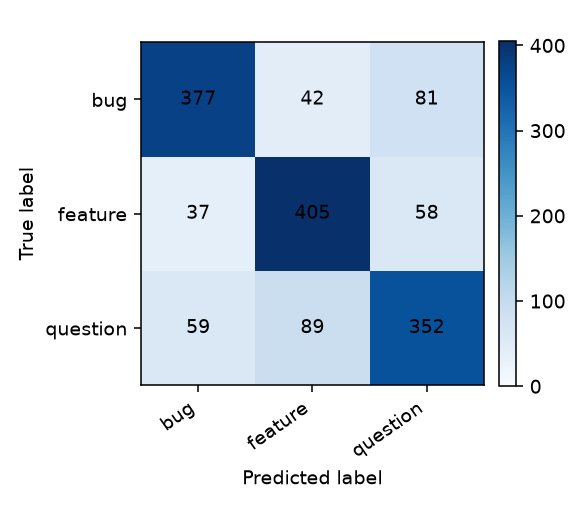

In [5]:
# Step 4: Display the aggregate primary-policy confusion matrix generated from final metrics.
confusion_figure = (
    PROJECT_ROOT / "report" / "generated" / "figures" /
    "chosen-model-confusion-matrix.png"
)
display(Image(filename=str(confusion_figure), width=600))


## Step 5 - Count the most frequent classification errors


In [6]:
# Step 5: Count wrong true/predicted label pairs across the primary test predictions.
primary_predictions = predictions.loc[predictions["policy"] == "primary"]
errors = primary_predictions.loc[
    primary_predictions["true_label"] != primary_predictions["predicted_label"]
]
error_counts = (
    errors.groupby(["repo", "true_label", "predicted_label"])
    .size()
    .rename("errors")
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
error_counts


,repo,true_label,predicted_label,errors
0,bitcoin/bitcoin,bug,question,34
1,facebook/react,question,feature,30
2,bitcoin/bitcoin,question,feature,23
3,microsoft/vscode,question,feature,23
4,tensorflow/tensorflow,question,bug,21
5,tensorflow/tensorflow,feature,question,20
6,microsoft/vscode,bug,question,18
7,microsoft/vscode,feature,bug,17
8,opencv/opencv,question,bug,17
9,opencv/opencv,bug,feature,16


## Step 6 - State the result directly


In [7]:
# Step 6: Print the final interpretation from the stored result.
hardest_label = class_scores["f1"].idxmin()
print(f"Chosen-model macro-F1: {primary['global']['macro_f1']:.6f}")
print(f"Strongest repository: {repository_scores.index[0]} ({repository_scores.iloc[0]:.6f})")
print(f"Weakest repository: {repository_scores.index[-1]} ({repository_scores.iloc[-1]:.6f})")
print(f"Hardest label: {hardest_label} ({class_scores.loc[hardest_label, 'f1']:.6f})")


Chosen-model macro-F1: 0.754385
Strongest repository: facebook/react (0.807182)
Weakest repository: bitcoin/bitcoin (0.700619)
Hardest label: question (0.710436)
